In [47]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [48]:
# importando parâmetros
struc_par_path = 'parameters/structural.csv'
inter_par_path = 'parameters/interaction.csv'
structural = pd.read_csv(struc_par_path, sep=';', decimal=',')
interaction = pd.read_csv(inter_par_path, sep=';', decimal=',')

R = structural[['Secondary', 'Volume R']].to_numpy()
Q = structural[['Secondary', 'Surface Area Q']].to_numpy()
A = interaction.iloc[:, 1:].to_numpy()

## Implementação UNIFAC

In [49]:
def get_species_parameters(secondary_groups:np.ndarray, rk:np.ndarray=R, qk:np.ndarray=Q) -> tuple[np.ndarray, np.ndarray]:
    # Ordenando vetores com base nos grupos secundários
    rk = rk[np.argsort(rk[:, 0])]
    qk = qk[np.argsort(qk[:, 0])]

    r = rk[np.searchsorted(rk[:, 0], secondary_groups), 1]
    q = qk[np.searchsorted(qk[:, 0], secondary_groups), 1]

    return r, q


def assemble_interaction_matrix(species:dict, temperature:float, amn:np.ndarray=A) -> np.ndarray:
    # Obtendo todos os grupos
    groups = np.array(sorted({
        (group[0], group[1])
        for molecule in species.values()
        for group in molecule
    }))
    # Índices dos grupos na tabela amn
    main_groups = groups[:, 0] - 1
    # Calculando parâmetro de interação com base no parâmetro de energia     
    psi_mn = np.exp(-amn[np.ix_(main_groups, main_groups)] / temperature)
    return psi_mn


def assemble_groups_matrix(species:dict) -> tuple[np.ndarray, np.ndarray]:
    # Montando arrays com grupos secundários
    data = np.array([
        [i, group[1], group[2]]
        for i, molecule in enumerate(species.values())
        for group in molecule
    ])
    # Obtendo grupos secundários únicos
    unique_sec = np.sort(np.unique(data[:, 1]))
    # Matriz de resposta
    arr = np.zeros((len(unique_sec), len(species)), dtype=int) 
    # Índices das linhas em data que contém os grupos secundários
    row_idx = np.searchsorted(unique_sec, data[:, 1])
    # Coluna i = espécie i
    col_idx = data[:, 0]
    # Montando matriz com valores de v_k
    arr[row_idx, col_idx] = data[:, 2]
    return unique_sec, arr


def combinatorial_contribution(composition:np.ndarray, group_matrix:np.ndarray, rk:np.ndarray, qk:np.ndarray, z:int) -> np.ndarray:
    ri = rk @ group_matrix
    qi = qk @ group_matrix
    li = z/2 * (ri - qi) - (ri - 1)
    # Calculo de phi_i
    den_phi = composition @ ri
    phi_i = (composition * ri) / den_phi
    # Calculo de theta_i
    den_theta = composition @ qi
    theta_i = (composition * qi) / den_theta
    # Ponderação de li
    l_mix = composition @ li
    # Contribuição combinatorial
    ln_comb = (
        np.log(phi_i/composition)
        + (z/2) * qi * np.log(theta_i/phi_i)
        + li
        - (phi_i/composition) * l_mix
    )
    return ln_comb


def calculate_group_lngamma(composition:np.ndarray, groups_matrix:np.ndarray, qk:np.ndarray, interaction_matrix:np.ndarray) -> np.ndarray:
    composition = np.atleast_2d(composition)
    # Calculando Xk
    arr_sum = groups_matrix.sum(axis=0)
    den = composition @ arr_sum
    xk = (composition @ groups_matrix.T) / den[:, None]
    
    # Calculando Theta_m
    den_theta = xk @ qk
    theta_m = (xk * qk) / den_theta[:, None]

    # Calculando ln Gamma i
    den = theta_m @ interaction_matrix
    term1 = np.log(den)
    term2 = (
        (interaction_matrix[None, :, :] * theta_m[:, None, :]) / den[:, None, :]
    ).sum(axis=2)
    ln_gamma = qk * (1 - term1 - term2)
    return ln_gamma


def residual_contribution(composition:np.ndarray, groups_matrix:np.ndarray, qk:np.ndarray, interaction_matrix:np.ndarray) -> np.ndarray:
    ln_gamma = calculate_group_lngamma(composition, groups_matrix, qk, interaction_matrix)
    ln_gamma_std = calculate_group_lngamma(np.identity(len(composition)), groups_matrix, qk, interaction_matrix)
    delta = ln_gamma - ln_gamma_std
    ln_res = np.sum(
        groups_matrix.T * delta,
        axis=1
    )
    return ln_res


def unifac(species:dict, composition:np.ndarray, temperature:float, z=10) -> np.ndarray:
    unique, group_matrix = assemble_groups_matrix(species)
    r, q = get_species_parameters(unique)
    ln_gamma_comb = combinatorial_contribution(composition, group_matrix, r, q, z)
    psi = assemble_interaction_matrix(species, temperature)
    ln_gamma_res = residual_contribution(composition, group_matrix, q, psi)
    return ln_gamma_res + ln_gamma_comb


# Função auxiliar para lidar com vetores de composição -> [n_pontos, n_espécies]
def unifac_vetorized(species:dict, composition:np.ndarray, temperature:float, z=10) -> np.ndarray:
    ln_gammas = np.zeros(composition.shape)
    for i, row in enumerate(composition):
        ln_gammas[i, :] = unifac(species, row, temperature)
    return ln_gammas

In [50]:
# Definindo parâmetros
temperatura = 307  # K
composicao = np.array([0.047, 0.953])

# Definindo moléculas e seus grupos
# Espécie1: [
#      [Main Group, Secondary Group, Qty]1,
#      [Main Group, Secondary Group, Qty]2,
#   ]
especies = {
    "1": [
        [1, 1 , 1],
        [9, 18, 1],
    ],
    "2": [
        [1, 1, 2],
        [1, 2, 3],
    ]
}


In [51]:
# Teste exemplo Reid and Prausnitz
ln_gammas = unifac(especies, composicao, temperatura)
print(f'gamma_acetona: {np.exp(ln_gammas[0])}')
print(f'gamma_n-pentano: {np.exp(ln_gammas[1])}')

gamma_acetona: 4.992034311484558
gamma_n-pentano: 1.005260211187879


## Exemplo dados reais

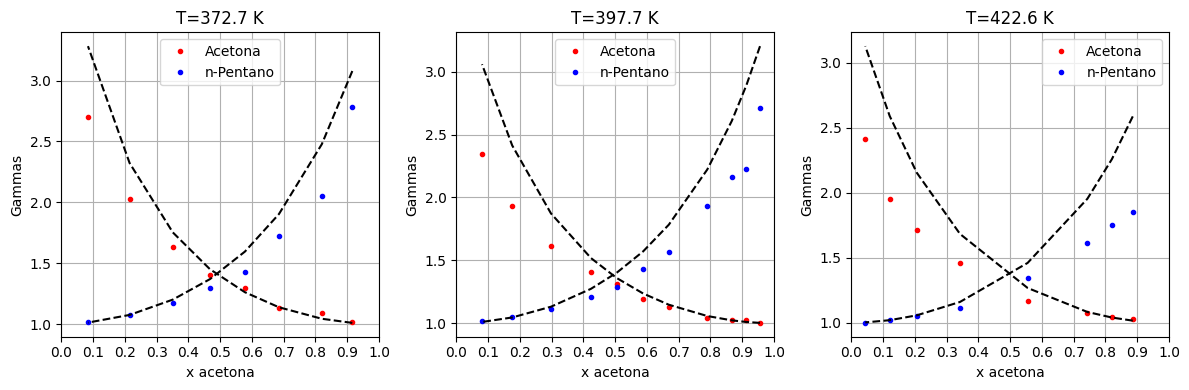

In [52]:
# Importando valores experimentais
with open('dados experimentais/acetona_n-pentano.json', 'r') as file:
    data = json.load(file)

# Criando gráficos
fig, ax = plt.subplots(1, len(data['Data']), figsize=(12, 4))

for i, v in enumerate(data['Data'].values()):
    temperatura = v['T [K]']
    x1 = np.array(v['x_acetona'])
    composicao = np.stack((x1, 1-x1), axis=1)
    g1_exp = np.exp(np.array(v['lng_acetona']))
    g2_exp = np.exp(np.array(v['lng_npentano']))
    # Resolvendo UNIFAC para frações molares experimentais
    gammas_unifac = np.exp(unifac_vetorized(especies, composicao, temperatura))

    # Plotando resultados
    ax[i].plot(x1, g1_exp, '.r', label='Acetona')
    ax[i].plot(x1, g2_exp, '.b', label='n-Pentano')
    ax[i].plot(x1, gammas_unifac[:, 0], '--k')
    ax[i].plot(x1, gammas_unifac[:, 1], '--k')
    ax[i].set_xticks(np.linspace(0, 1, 11))
    ax[i].grid()
    ax[i].set_title(f'T={temperatura} K')
    ax[i].set_xlabel('x acetona')
    ax[i].set_ylabel('Gammas')
    ax[i].legend()

plt.tight_layout()
plt.show()


## Exemplo 2: Sistema Etanol + 2-butanona

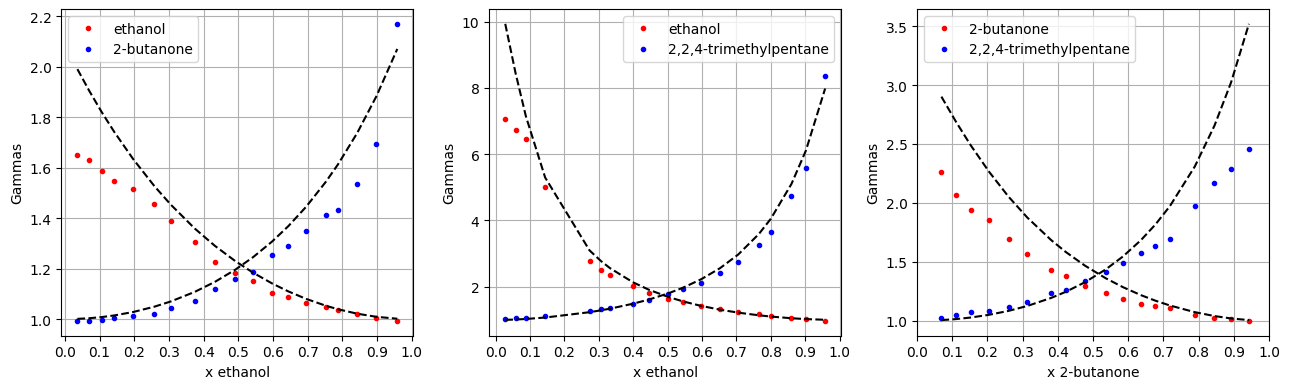

In [53]:
# Importando valores experimentais
with open('dados experimentais/etanol_2-butanona_224-trimetilpentano.json', 'r') as file:
    data = json.load(file)

etanol = [
        [1, 1 , 1], # CH3
        [1, 2 , 1], # CH2
        [5, 14, 1], # OH
    ]

butanona = [
        [1, 1, 1],  # CH3
        [1, 2, 1],  # CH2
        [9, 18, 1], # CH3CO
    ]

trimetilpentano = [
    [1, 1, 5], # CH3
    [1, 2, 1], # CH2
    [1, 3, 1], # CH
    [1, 4, 1], # C
]
especies1 = {
    "1": etanol,
    "2": butanona
}
especies2 = {
    "1": etanol,
    "2": trimetilpentano 
}
especies3 = {
    "1": butanona,
    "2": trimetilpentano 
}
binarios = [especies1, especies2, especies3]

# Criando gráficos
fig, ax = plt.subplots(1, len(binarios), figsize=(13, 4))

for k, esp in enumerate(binarios):
    dados = data['Data'][str(k + 1)]
    temperaturas = np.array(dados['T [K]'])
    x1 = np.array(dados['x_1'])
    composicao = np.stack((x1, 1-x1), axis=1)
    g1_exp = np.array(dados['gamma_1'])
    g2_exp = np.array(dados['gamma_2'])

    gammas_unifac = np.zeros(composicao.shape)
    for i, row in enumerate(composicao):
        # Resolvendo UNIFAC para frações molares experimentais
        gammas_unifac[i, :] = np.exp(unifac(esp, row, temperaturas[i]))

    
    # Plotando resultados
    sp1, sp2 = dados['especies'].split(' + ')
    ax[k].plot(x1, g1_exp, '.r', label=sp1)
    ax[k].plot(x1, g2_exp, '.b', label=sp2)
    ax[k].plot(x1, gammas_unifac[:, 0], '--k')
    ax[k].plot(x1, gammas_unifac[:, 1], '--k')
    ax[k].set_xticks(np.linspace(0, 1, 11))
    ax[k].grid()
    ax[k].set_xlabel(f'x {sp1}')
    ax[k].set_ylabel('Gammas')
    ax[k].legend()

plt.tight_layout()
plt.show()


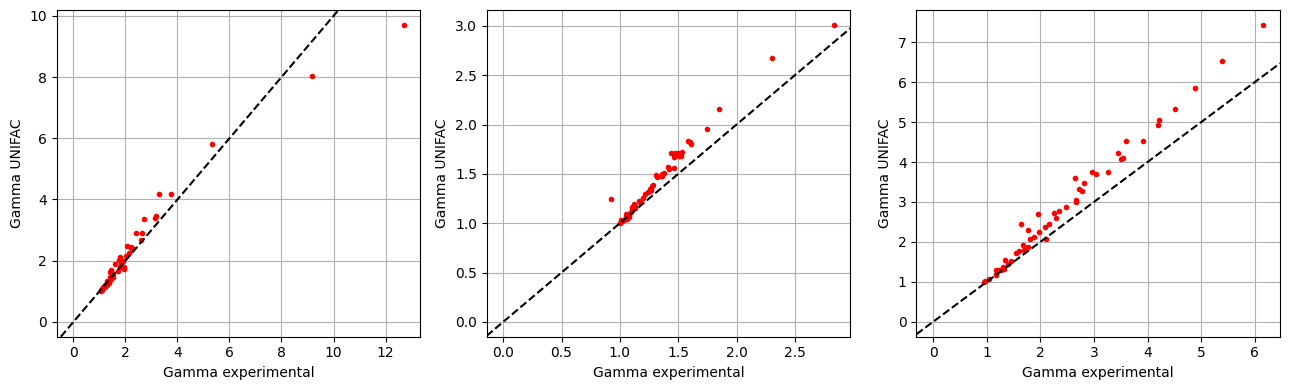

In [ ]:
# Ternario
especies = {
    "1": etanol,
    "2": butanona,
    "3": trimetilpentano
}
dados_ternario = data['Data']['4']
temperaturas = np.array(dados_ternario['T [K]'])
x1 = np.array(dados_ternario['x_1'])
x2 = np.array(dados_ternario['x_2'])
composicao = np.stack((x1, x2, 1-x1-x2), axis=1)
g1_exp = np.array(dados_ternario['gamma_1'])
g2_exp = np.array(dados_ternario['gamma_2'])
g3_exp = np.array(dados_ternario['gamma_3'])

gammas_unifac = np.zeros(composicao.shape)
for i, row in enumerate(composicao):
    # Resolvendo UNIFAC para frações molares experimentais
    gammas_unifac[i, :] = np.exp(unifac(especies, row, temperaturas[i]))

fig, ax = plt.subplots(1, len(gammas_unifac.T), figsize=(13, 4))

for i, g_exp in enumerate([g1_exp, g2_exp, g3_exp]):
    ax[i].plot(g_exp, gammas_unifac[:, i], '.r')
    ax[i].axline((0, 0), slope=1, color='black', linestyle='--')
    ax[i].set_title(f'Gamma {i + 1}')
    ax[i].grid()
    ax[i].set_xlabel('Gamma experimental')
    ax[i].set_ylabel('Gamma UNIFAC')

plt.tight_layout()
plt.show()